In [1]:
import xradar as xd
import xarray as xr
import fsspec
import cmweather
import numpy as np

In [2]:
filepath = 's3://noaa-nexrad-level2/2011/05/20/KVNX/KVNX20110520_000442_V06.gz'
storage_options = {"anon": True}
stream = fsspec.open(filepath, mode="rb", compression= "gzip", **storage_options).open()


In [3]:
dtree = xd.io.open_nexradlevel2_datatree(stream.read())

In [4]:
dtree = dtree.xradar.georeference()

In [27]:
dtree

<xarray.DataTree>
Group: /
│   Dimensions:              ()
│   Data variables:
│       volume_number        int64 8B 0
│       platform_type        <U5 20B 'fixed'
│       instrument_type      <U5 20B 'radar'
│       time_coverage_start  <U20 80B '2011-05-20T00:04:42Z'
│       time_coverage_end    <U20 80B '2011-05-20T00:08:51Z'
│       longitude            float64 8B -98.13
│       altitude             int64 8B 378
│       latitude             float64 8B 36.74
│   Attributes:
│       Conventions:      None
│       instrument_name:  KVNX
│       version:          None
│       title:            None
│       institution:      None
│       references:       None
│       source:           None
│       history:          None
│       comment:          im/exported using xradar
│       scan_name:        VCP-12
├── Group: /sweep_0
│       Dimensions:            (azimuth: 720, range: 1832)
│       Coordinates:
│         * azimuth            (azimuth) float64 6kB 0.2637 0.7306 1.236 ... 359.3 359.7
│           elevation          (azimuth) float64 6kB 0.5273 0.5273 ... 0.5273 0.5273
│           time               (azimuth) datetime64[ns] 6kB ...
│           range              (range) float32 7kB 2.125e+03 2.375e+03 ... 4.599e+05
│           longitude          float64 8B -98.13
│           latitude           float64 8B 36.74
│           altitude           int64 8B 378
│           crs_wkt            int64 8B 0
│           z                  (azimuth, range) float64 11MB 397.8 400.2 ... 1.704e+04
│         * x                  (azimuth, range) float64 11MB 9.778 10.93 ... -2.157e+03
│         * y                  (azimuth, range) float64 11MB 2.125e+03 ... 4.592e+05
│       Data variables:
│           DBZH               (azimuth, range) float64 11MB ...
│           ZDR                (azimuth, range) float64 11MB ...
│           PHIDP              (azimuth, range) float64 11MB ...
│           RHOHV              (azimuth, range) float64 11MB ...
│           sweep_mode         <U20 80B 'azimuth_surveillance'
│           sweep_number       int64 8B 0
│           prt_mode           <U7 28B 'not_set'
│           follow_mode        <U7 28B 'not_set'
│           sweep_fixed_angle  float64 8B 0.4834
│       Indexes:
│         ┌ x        NDPointIndex (ScipyKDTreeAdapter)
│         └ y
├── Group: /sweep_1
│       Dimensions:            (azimuth: 720, range: 1192)
│       Coordinates:
│         * azimuth            (azimuth) float64 6kB 0.2362 0.7581 1.252 ... 359.2 359.8
│           elevation          (azimuth) float64 6kB 0.5273 0.5273 ... 0.5273 0.5273
│           time               (azimuth) datetime64[ns] 6kB ...
│           range              (range) float32 5kB 2.125e+03 2.375e+03 ... 2.999e+05
│           longitude          float64 8B -98.13
│           latitude           float64 8B 36.74
│           altitude           int64 8B 378
│           crs_wkt            int64 8B 0
│           z                  (azimuth, range) float64 7MB 397.8 400.2 ... 8.427e+03
│         * x                  (azimuth, range) float64 7MB 8.76 9.79 ... -1.207e+03
│         * y                  (azimuth, range) float64 7MB 2.125e+03 ... 2.996e+05
│       Data variables:
│           DBZH               (azimuth, range) float64 7MB ...
│           VRADH              (azimuth, range) float64 7MB ...
│           WRADH              (azimuth, range) float64 7MB ...
│           sweep_mode         <U20 80B 'azimuth_surveillance'
│           sweep_number       int64 8B 1
│           prt_mode           <U7 28B 'not_set'
│           follow_mode        <U7 28B 'not_set'
│           sweep_fixed_angle  float64 8B 0.4834
│       Indexes:
│         ┌ x        NDPointIndex (ScipyKDTreeAdapter)
│         └ y
├── Group: /sweep_2
│       Dimensions:            (azimuth: 720, range: 1832)
│       Coordinates:
│         * azimuth            (azimuth) float64 6kB 0.2472 0.7361 1.269 ... 359.2 359.7
│           elevation          (azimuth) float64 6kB 0.9229 0.9229 ... 0.9229 0.9229
│        

In [5]:
def set_ndindex(ds):
    return ds.set_xindex(("x", "y"), xr.indexes.NDPointIndex)

In [6]:
dtree = dtree.xradar.map_over_sweeps(set_ndindex)

In [19]:
ds = dtree["sweep_4"].ds

In [25]:
# ds

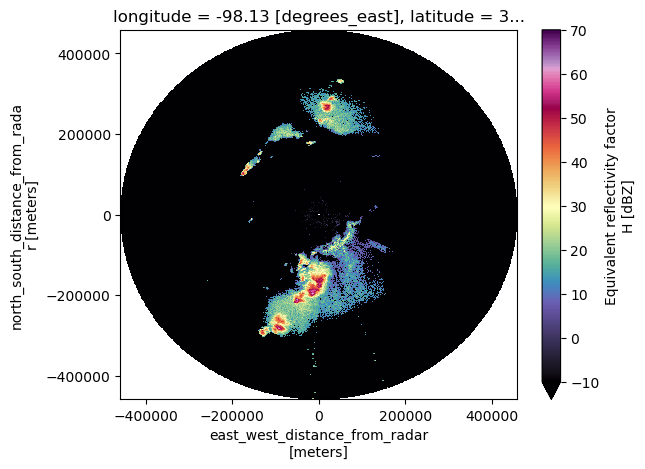

In [26]:
dtree["sweep_4"].DBZH.plot(
    x="x",
    y="y",
    cmap="ChaseSpectral",
    vmin=-10,
    vmax=70
)

In [22]:
y = xr.DataArray(np.arange(-25e4, -50e2, 500), dims="y", name="y", attrs=ds.y.attrs)
x = xr.DataArray(np.arange(-15e4, 100e3, 500), dims="x", name="x", attrs=ds.x.attrs)

In [23]:
actual = ds.sel(y=y, x=x, method="nearest")

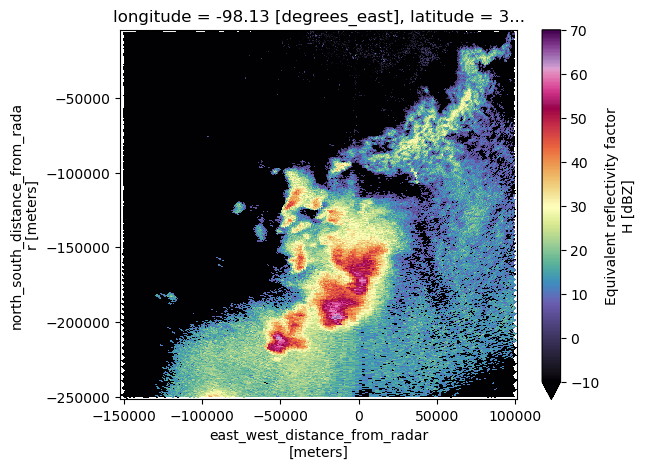

In [24]:
actual.DBZH.plot(
    x="x",
    y="y",
    cmap="ChaseSpectral",
    vmin=-10,
    vmax=70
)